# 01 — Data, sample definition and target

**Goal:** turn 2.2M raw LendingClub loans into a clean modelling dataset with a
defensible default definition — and avoid the two classic traps: **data leakage**
and **resolution bias**.

Input: the Kaggle file in `data/raw/` (see README).

In [1]:
import os, sys, pickle
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pdmodel import config as C
pd.set_option("display.float_format", "{:.4f}".format)
PROC = ROOT / "data" / "processed"
from pdmodel import data, plots

## 1. Load only what we need
The raw file has 151 columns. We read 24: information known **at application time**,
plus `loan_status` (the outcome) and `grade` / `sub_grade` / `int_rate` (benchmark only, never model inputs).

In [2]:
DATA_PATH = os.environ.get("PD_DATA_PATH")   # None -> auto-find in data/raw/
raw = data.load_raw(DATA_PATH)
print(raw.shape)
raw.head()

(2260701, 24)


,loan_amnt,term,int_rate,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,...,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc
0,3600.0000,36 months,13.9900,C,C4,10+ years,MORTGAGE,55000.0000,Not Verified,Dec-2015,...,Aug-2003,675.0000,679.0000,1.0000,7.0000,0.0000,2765.0000,29.7000,13.0000,1.0000
1,24700.0000,36 months,11.9900,C,C1,10+ years,MORTGAGE,65000.0000,Not Verified,Dec-2015,...,Dec-1999,715.0000,719.0000,4.0000,22.0000,0.0000,21470.0000,19.2000,38.0000,4.0000
2,20000.0000,60 months,10.7800,B,B4,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,...,Aug-2000,695.0000,699.0000,0.0000,6.0000,0.0000,7869.0000,56.2000,18.0000,5.0000
3,35000.0000,60 months,14.8500,C,C5,10+ years,MORTGAGE,110000.0000,Source Verified,Dec-2015,...,Sep-2008,785.0000,789.0000,0.0000,13.0000,0.0000,7802.0000,11.6000,17.0000,1.0000
4,10400.0000,60 months,22.4500,F,F1,3 years,MORTGAGE,104433.0000,Source Verified,Dec-2015,...,Jun-1998,695.0000,699.0000,3.0000,12.0000,0.0000,21929.0000,64.5000,35.0000,6.0000


In [3]:
raw["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

## 2. Target definition
| `loan_status` | Treatment |
|---|---|
| Fully Paid | good (0) |
| Charged Off, Default | bad (1) |
| Current, Late, In Grace Period | **excluded** — outcome not yet known |

**Why only 36-month loans issued ≤ 2015?** The data snapshot ends in 2018Q4. A loan
issued in 2017 that has already *finished* is more likely to be an early default
(or early prepayment) than a typical loan — keeping it would bias the default rate.
Restricting to vintages that have had 36 months to mature avoids this.

In [4]:
df = data.prepare(raw)
print(f"{len(df):,} loans after sample definition, default rate {df['default'].mean():.2%}")
df.head()

621,022 loans after sample definition, default rate 13.95%


,issue_d,issue_year,default,sub_grade,grade,int_rate,loan_amnt,annual_inc,loan_to_income,dti,...,open_acc,total_acc,revol_bal,revol_util,delinq_2yrs,pub_rec,mort_acc,home_ownership,purpose,verification_status
0,2015-12-01,2015,0,C4,C,13.9900,3600.0000,55000.0000,0.0655,5.9100,...,7.0000,13.0000,2765.0000,29.7000,0.0000,0.0000,1.0000,MORTGAGE,debt_consolidation,Not Verified
1,2015-12-01,2015,0,C1,C,11.9900,24700.0000,65000.0000,0.3800,16.0600,...,22.0000,38.0000,21470.0000,19.2000,1.0000,0.0000,4.0000,MORTGAGE,small_business,Not Verified
2,2015-12-01,2015,0,C3,C,13.4400,11950.0000,34000.0000,0.3515,10.2000,...,5.0000,6.0000,8822.0000,68.4000,0.0000,0.0000,0.0000,RENT,debt_consolidation,Source Verified
3,2015-12-01,2015,0,B2,B,9.1700,20000.0000,180000.0000,0.1111,14.6700,...,12.0000,27.0000,87329.0000,84.5000,0.0000,0.0000,4.0000,MORTGAGE,debt_consolidation,Not Verified
4,2015-12-01,2015,0,B1,B,8.4900,20000.0000,85000.0000,0.2353,17.6100,...,8.0000,15.0000,826.0000,5.7000,1.0000,0.0000,3.0000,MORTGAGE,major_purchase,Not Verified


## 3. Default rate by vintage
If later vintages default more, a model built on old vintages will **under-predict**
PD on new ones. The out-of-time test in notebook 04 checks exactly this.

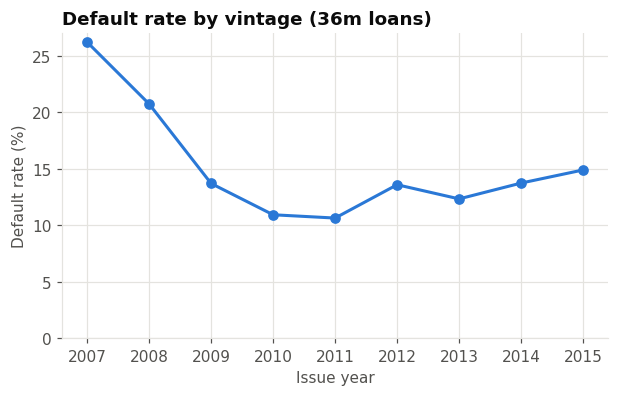

,n,default_rate
issue_year,,
2007,603,0.2620
2008,2393,0.2073
2009,5281,0.1369
2010,9156,0.1092
2011,14101,0.1063
2012,43470,0.1358
2013,100422,0.1233
2014,162570,0.1373
2015,283026,0.1489


In [5]:
plots.default_rate_by_vintage(df); plt.show()
df.groupby("issue_year")["default"].agg(n="size", default_rate="mean")

## 4. Train / test / out-of-time split
- **Train / test**: random 70/30 split of vintages ≤ 2013 (stratified on default).
- **OOT**: vintages 2014–2015 — the model never sees them.

A bank validator cares most about the OOT numbers: they show how the model
behaves on *future* borrowers.

In [6]:
S = data.split_samples(df)
data.sample_summary(S)

,n_loans,n_defaults,default_rate,first_issue,last_issue
sample,,,,,
train,122798,15510,0.1263,2007-06,2013-12
test,52628,6647,0.1263,2007-06,2013-12
oot,445596,64447,0.1446,2014-01,2015-12


## 5. Missing values
WoE binning gives missing values their own bin, so no imputation is needed. The reason for
missingness still matters: `mort_acc` is blank for every loan issued before 2012 because
LendingClub only started recording it then. Its "Missing" bin would act as a vintage flag,
so features missing for more than 10% of training loans are dropped at selection (notebook 03).

In [7]:
S["train"][C.NUMERIC_FEATURES + C.CATEGORICAL_FEATURES].isna().mean().sort_values(ascending=False).head(8)

mort_acc            0.2129
emp_length_yrs      0.0433
revol_util          0.0011
total_acc           0.0002
pub_rec             0.0002
credit_hist_years   0.0002
inq_last_6mths      0.0002
open_acc            0.0002
dtype: float64

In [8]:
PROC.mkdir(parents=True, exist_ok=True)
pd.to_pickle(S, PROC / "samples.pkl")
print("saved data/processed/samples.pkl")

saved data/processed/samples.pkl


## Findings
- 621,022 resolved 36-month loans: 175,426 in development (2007–13) and 445,596 out of time (2014–15).
- Default rates bottomed at 10.6% for 2011 loans and rose every year to 14.9% for 2015 loans,
  so the out-of-time default rate (14.5%) is above the development rate (12.6%).
- `mort_acc` is 100% missing for 2007–11 loans and 14% missing for 2012 loans.